# Kunci Jawaban - Linear Regression

- **Dataset:** [Appliances Energy Prediction](https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction)
- **Target:** `Appliances`
- **Jenis masalah:** Regression
- **Model:** Linear Regression

## 1 - Setup

### Install library tambahan

Install `ucimlrepo` terlebih dahulu agar dataset dari UCI Machine Learning Repository bisa diambil langsung di Google Colab.

In [1]:
%pip install -q ucimlrepo

### Import library utama

Import library utama berikut:

- `warnings`: mengatur tampilan warning.
- `numpy`: membantu perhitungan numerik, terutama RMSE.
- `pandas`: membaca, menyimpan, dan mengolah data berbentuk tabel.
- `matplotlib.pyplot`: membuat visualisasi dasar seperti histogram, bar plot, scatter plot, dan boxplot.
- `seaborn`: membuat visualisasi statistik seperti histogram dengan KDE, bar plot, dan regression plot.

In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import fungsi dan class tambahan

Import fungsi dan class berikut dari package yang lebih besar:

- `fetch_ucirepo`: mengambil dataset langsung dari UCI Machine Learning Repository.
- `train_test_split`: membagi data menjadi data train dan data test.
- `StandardScaler`: menyamakan skala fitur numerik.
- `LinearRegression`: membuat dan melatih model regresi linear.
- `mean_absolute_error`: menghitung MAE.
- `mean_squared_error`: menghitung MSE dan RMSE.
- `r2_score`: menghitung R2 Score.

In [3]:
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Matikan warning yang tidak diperlukan

Matikan warning agar tampilan notebook lebih bersih.

In [4]:
warnings.filterwarnings("ignore")

### Atur tampilan angka

Atur tampilan angka agar tabel lebih mudah dibaca.

In [5]:
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="whitegrid")

## 2 - Load Dataset

### Ambil dataset dari UCI

Ambil dataset Appliances Energy Prediction menggunakan ID dataset dari UCI.

In [6]:
appliances = fetch_ucirepo(id=374)

### Ambil fitur dari dataset

Simpan fitur dataset ke variabel `X_raw`.

In [7]:
X_raw = appliances.data.features.copy()

### Ambil target dari dataset

Simpan target dataset ke variabel `y_raw`.

In [8]:
y_raw = appliances.data.targets.copy()

### Tentukan kolom target

Tentukan kolom `Appliances` sebagai target prediksi.

In [9]:
TARGET_COL = "Appliances"

### Gabungkan fitur dan target

Gabungkan fitur dan target menjadi satu DataFrame bernama `df`.

In [10]:
df = pd.concat([X_raw, y_raw], axis=1)

### Tampilkan ukuran dataset

Tampilkan jumlah baris dan kolom pada dataset.

In [11]:
df.shape

(19735, 29)

> Berdasarkan output, berapa jumlah baris dan kolom pada dataset?

Jawaban: Dataset memiliki 19735 baris dan 29 kolom.

### Tampilkan lima baris pertama

Tampilkan lima baris pertama untuk melihat contoh isi data.

In [12]:
df.head()

,date,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,Appliances
0,2016-01-1117:00:00,30,19.890,47.597,19.200,44.790,19.790,44.730,19.000,45.567,...,45.530,6.600,733.500,92.000,7.000,63.000,5.300,13.275,13.275,60
1,2016-01-1117:10:00,30,19.890,46.693,19.200,44.722,19.790,44.790,19.000,45.992,...,45.560,6.480,733.600,92.000,6.667,59.167,5.200,18.606,18.606,60
2,2016-01-1117:20:00,30,19.890,46.300,19.200,44.627,19.790,44.933,18.927,45.890,...,45.500,6.370,733.700,92.000,6.333,55.333,5.100,28.643,28.643,50
3,2016-01-1117:30:00,40,19.890,46.067,19.200,44.590,19.790,45.000,18.890,45.723,...,45.400,6.250,733.800,92.000,6.000,51.500,5.000,45.410,45.410,50
4,2016-01-1117:40:00,40,19.890,46.333,19.200,44.530,19.790,45.000,18.890,45.530,...,45.400,6.130,733.900,92.000,5.667,47.667,4.900,10.084,10.084,60


> Berdasarkan lima baris pertama, kolom apa yang menjadi target prediksi?

Jawaban: Kolom target prediksi adalah `Appliances`.

> Kolom mana yang terlihat berisi teks waktu?

Jawaban: Kolom `date` berisi teks waktu.

## 3 - Data Understanding

### Tampilkan informasi dataset

Tampilkan informasi struktur dataset menggunakan `info()`.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   lights       19735 non-null  int64  
 2   T1           19735 non-null  float64
 3   RH_1         19735 non-null  float64
 4   T2           19735 non-null  float64
 5   RH_2         19735 non-null  float64
 6   T3           19735 non-null  float64
 7   RH_3         19735 non-null  float64
 8   T4           19735 non-null  float64
 9   RH_4         19735 non-null  float64
 10  T5           19735 non-null  float64
 11  RH_5         19735 non-null  float64
 12  T6           19735 non-null  float64
 13  RH_6         19735 non-null  float64
 14  T7           19735 non-null  float64
 15  RH_7         19735 non-null  float64
 16  T8           19735 non-null  float64
 17  RH_8         19735 non-null  float64
 18  T9           19735 non-null  float64
 19  RH_9

> Berdasarkan output `info()`, apa tipe data yang muncul pada dataset?

Jawaban: Dataset memiliki tipe data `object`, `int64`, dan `float64`.

> Apakah jumlah non-null menunjukkan adanya missing value?

Jawaban: Tidak. Semua kolom memiliki 19735 non-null, sama dengan jumlah baris dataset.

### Cek missing value

Hitung jumlah missing value pada setiap kolom.

In [14]:
df.isna().sum()

date           0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
Appliances     0
dtype: int64

> Berdasarkan output, kolom mana yang memiliki missing value?

Jawaban: Tidak ada kolom yang memiliki missing value.

### Cek jumlah duplikat

Hitung jumlah baris duplikat penuh pada dataset.

In [15]:
df.duplicated().sum()

np.int64(0)

> Berdasarkan output, berapa jumlah baris duplikat penuh?

Jawaban: Jumlah baris duplikat penuh adalah 0.

### Tampilkan statistik deskriptif

Tampilkan statistik deskriptif untuk kolom numerik dan teks.

In [16]:
df.describe(include="all")

,date,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,Appliances
count,19735,19735.000,19735.000,19735.000,19735.000,19735.000,19735.000,19735.000,19735.000,19735.000,...,19735.000,19735.000,19735.000,19735.000,19735.000,19735.000,19735.000,19735.000,19735.000,19735.000
unique,19735,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2016-05-2718:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,3.802,21.687,40.260,20.341,40.420,22.268,39.243,20.855,39.027,...,41.552,7.413,755.523,79.750,4.040,38.331,3.761,24.988,24.988,97.695
std,NaN,7.936,1.606,3.979,2.193,4.070,2.006,3.255,2.043,4.341,...,4.151,5.318,7.399,14.901,2.451,11.795,4.195,14.497,14.497,102.525
min,NaN,0.000,16.790,27.023,16.100,20.463,17.200,28.767,15.100,27.660,...,29.167,-5.000,729.300,24.000,0.000,1.000,-6.600,0.005,0.005,10.000
25%,NaN,0.000,20.760,37.333,18.790,37.900,20.790,36.900,19.530,35.530,...,38.500,3.670,750.933,70.333,2.000,29.000,0.900,12.498,12.498,50.000
50%,NaN,0.000,21.600,39.657,20.000,40.500,22.100,38.530,20.667,38.400,...,40.900,6.920,756.100,83.667,3.667,40.000,3.430,24.898,24.898,60.000
75%,NaN,0.000,22.600,43.067,21.500,43.260,23.290,41.760,22.100,42.157,...,44.338,10.400,760.933,91.667,5.500,40.000,6.570,37.584,37.584,100.000


> Berdasarkan statistik deskriptif, berapa rata-rata target `Appliances`?

Jawaban: Rata-rata target `Appliances` sekitar 97.695.

> Berdasarkan statistik deskriptif, apakah kolom `date` memiliki nilai unik untuk setiap baris?

Jawaban: Ya. Kolom `date` memiliki 19735 nilai unik, sama dengan jumlah baris dataset.

## 4 - Data Cleaning

### Hapus baris duplikat

Hapus baris duplikat penuh agar data lebih bersih.

In [17]:
df_clean = df.drop_duplicates().copy()

### Reset index dataset

Reset index setelah proses cleaning.

In [18]:
df_clean = df_clean.reset_index(drop=True)

### Cek ukuran data setelah cleaning

Tampilkan ukuran dataset setelah proses cleaning.

In [19]:
df_clean.shape

(19735, 29)

> Berdasarkan output, berapa ukuran dataset setelah duplikat dihapus?

Jawaban: Ukuran dataset tetap 19735 baris dan 29 kolom.

### Cek ulang duplikat

Pastikan tidak ada baris duplikat penuh setelah cleaning.

In [20]:
df_clean.duplicated().sum()

np.int64(0)

> Berdasarkan output, apakah masih ada baris duplikat setelah cleaning?

Jawaban: Tidak ada baris duplikat setelah cleaning.

## 5 - Exploratory Data Analysis

### Tampilkan statistik target

Tampilkan statistik deskriptif khusus untuk target `Appliances`.

In [21]:
df_clean[TARGET_COL].describe()

count   19735.000
mean       97.695
std       102.525
min        10.000
25%        50.000
50%        60.000
75%       100.000
max      1080.000
Name: Appliances, dtype: float64

> Berdasarkan output, berapa nilai mean, minimum, dan maksimum target?

Jawaban: Mean target sekitar 97.695, minimum 10.000, dan maksimum 1080.000.

### Buat histogram target

Gunakan histogram dengan KDE untuk melihat distribusi target `Appliances`.

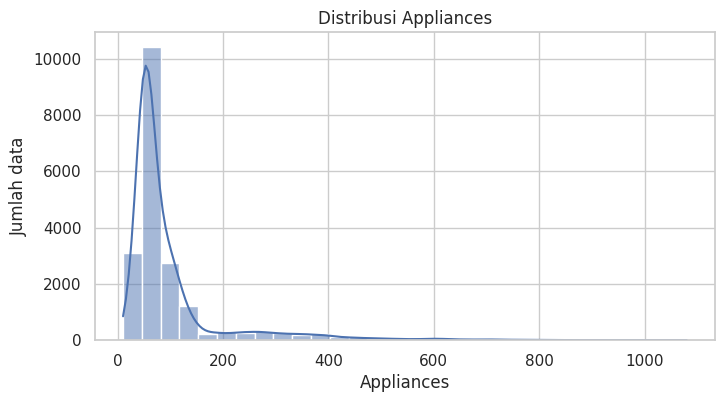

In [22]:
plt.figure(figsize=(8, 4))
sns.histplot(df_clean[TARGET_COL], bins=30, kde=True)
plt.title("Distribusi Appliances")
plt.xlabel("Appliances")
plt.ylabel("Jumlah data")
plt.show()

> Berdasarkan histogram, di rentang mana nilai target paling banyak muncul?

Jawaban: Nilai target paling banyak muncul pada rentang sekitar 45.667 sampai 81.333.

> Apakah distribusi target terlihat simetris atau cenderung miring?

Jawaban: Distribusi target cenderung miring ke kanan karena ada konsumsi energi yang jauh lebih tinggi.

### Hitung korelasi fitur numerik dengan target

Hitung korelasi fitur numerik terhadap target tanpa memakai kolom acak `rv1` dan `rv2`.

In [23]:
numeric_corr = df_clean.drop(columns=["rv1", "rv2"]).select_dtypes(include="number").corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
numeric_corr

lights         0.197
T2             0.120
T6             0.118
T_out          0.099
Windspeed      0.087
RH_1           0.086
T3             0.085
T1             0.055
T4             0.040
T8             0.040
RH_3           0.036
T7             0.026
T5             0.020
RH_4           0.017
Tdewpoint      0.015
T9             0.010
RH_5           0.007
Visibility     0.000
Press_mm_hg   -0.035
RH_9          -0.051
RH_7          -0.056
RH_2          -0.060
RH_6          -0.083
RH_8          -0.094
RH_out        -0.152
Name: Appliances, dtype: float64

> Berdasarkan output korelasi, fitur apa yang memiliki korelasi positif paling tinggi terhadap target?

Jawaban: Fitur `lights` memiliki korelasi positif paling tinggi terhadap target.

> Fitur apa yang memiliki korelasi negatif paling kuat terhadap target?

Jawaban: Fitur `RH_out` memiliki korelasi negatif paling kuat terhadap target.

### Buat bar plot korelasi numerik

Gunakan bar plot untuk melihat kekuatan korelasi fitur numerik dengan target.

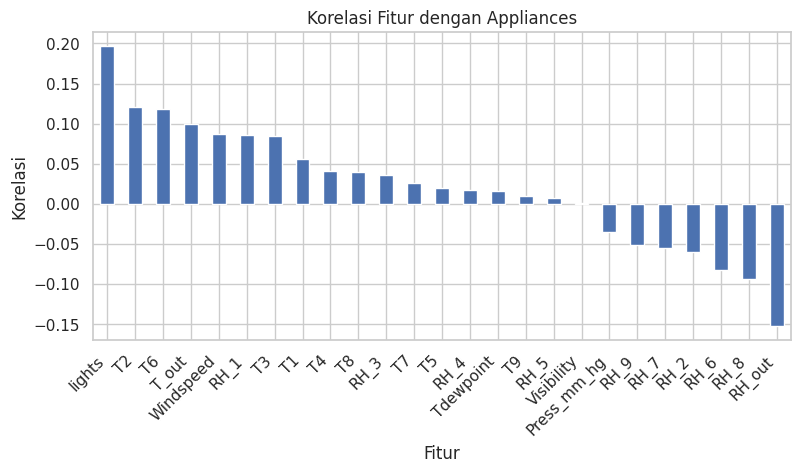

In [24]:
plt.figure(figsize=(9, 4))
numeric_corr.plot(kind="bar")
plt.title("Korelasi Fitur dengan Appliances")
plt.xlabel("Fitur")
plt.ylabel("Korelasi")
plt.xticks(rotation=45, ha="right")
plt.show()

> Berdasarkan bar plot, fitur mana yang paling positif hubungannya dengan target?

Jawaban: `lights` paling positif hubungannya dengan target.

> Fitur mana yang paling negatif hubungannya dengan target?

Jawaban: `RH_out` paling negatif hubungannya dengan target.

### Buat bar plot rata-rata target berdasarkan lights

Gunakan bar plot untuk melihat rata-rata `Appliances` pada setiap nilai `lights`.

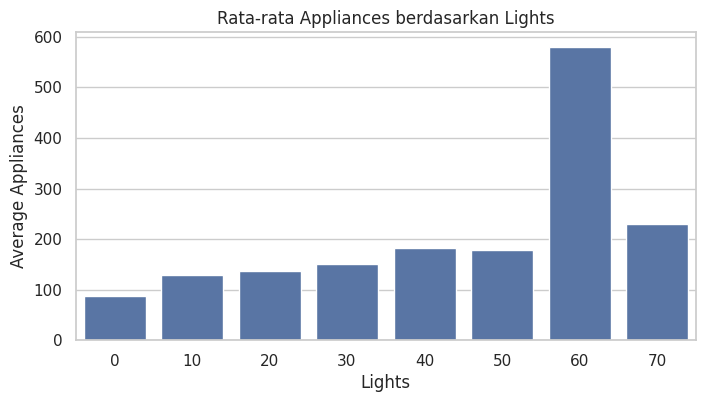

In [25]:
lights_mean = df_clean.groupby("lights")[TARGET_COL].mean().reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=lights_mean, x="lights", y=TARGET_COL)
plt.title("Rata-rata Appliances berdasarkan Lights")
plt.xlabel("Lights")
plt.ylabel("Average Appliances")
plt.show()

> Berdasarkan bar plot, nilai `lights` mana yang memiliki rata-rata target paling tinggi?

Jawaban: Nilai `lights` 60 memiliki rata-rata target paling tinggi.

> Mengapa bar plot rata-rata lebih tepat daripada scatter plot untuk `lights`?

Jawaban: Bar plot rata-rata lebih tepat karena `lights` memiliki nilai diskrit yang terbatas.

### Buat scatter plot T2 dan target

Gunakan scatter plot dengan garis regresi untuk melihat hubungan fitur suhu `T2` dengan target.

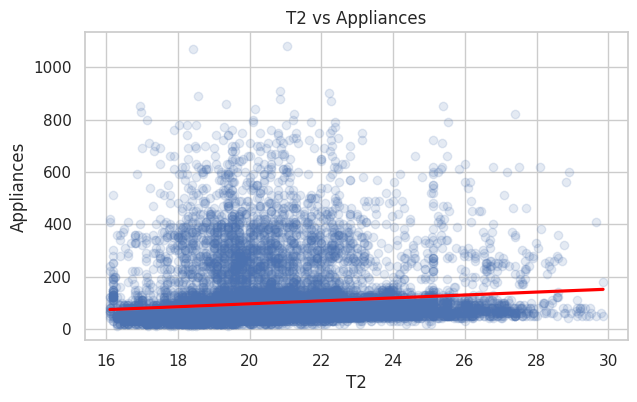

In [26]:
plt.figure(figsize=(7, 4))
sns.regplot(data=df_clean, x="T2", y=TARGET_COL, scatter_kws={"alpha": 0.15}, line_kws={"color": "red"})
plt.title("T2 vs Appliances")
plt.xlabel("T2")
plt.ylabel("Appliances")
plt.show()

> Berdasarkan scatter plot, bagaimana pola hubungan `T2` dengan target?

Jawaban: Polanya cenderung positif tetapi tidak terlalu kuat; titik data masih menyebar cukup lebar.

> Mengapa scatter plot masih sesuai untuk kolom `T2`?

Jawaban: Scatter plot sesuai karena `T2` adalah fitur numerik yang cukup kontinu.

## 6 - Feature dan Target

### Pisahkan fitur awal

Pisahkan fitur awal dengan menghapus target, tanggal mentah, dan kolom acak.

In [27]:
X_raw_model = df_clean.drop(columns=[TARGET_COL, "date", "rv1", "rv2"])

### Pisahkan target

Simpan kolom target ke dalam variabel `y`.

In [28]:
y = df_clean[TARGET_COL]

### Gunakan fitur numerik

Gunakan fitur numerik yang sudah tersedia karena kolom teks dan kolom acak sudah dihapus.

In [29]:
X = X_raw_model.copy()

### Tampilkan ukuran fitur

Tampilkan ukuran `X` yang akan digunakan untuk modeling.

In [30]:
X.shape

(19735, 25)

> Berdasarkan output, berapa jumlah baris dan fitur pada `X`?

Jawaban: `X` memiliki 19735 baris dan 25 fitur.

### Tampilkan ukuran target

Tampilkan ukuran `y` sebagai target model.

In [31]:
y.shape

(19735,)

> Berdasarkan output, berapa jumlah nilai target pada `y`?

Jawaban: `y` memiliki 19735 nilai target.

## 7 - Train-Test Split

### Tentukan parameter split

Tentukan `test_size` dan `random_state` yang akan digunakan.

In [32]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

> Berdasarkan nilai `test_size`, berapa persen data uji dan berapa persen data latih yang digunakan?

Jawaban: Data uji sebanyak 20% dan data latih sebanyak 80%.

### Bagi data train dan test

Bagi fitur dan target menjadi data train dan data test.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

### Tampilkan ukuran X_train

Tampilkan ukuran fitur pada data train.

In [34]:
X_train.shape

(15788, 25)

### Tampilkan ukuran X_test

Tampilkan ukuran fitur pada data test.

In [35]:
X_test.shape

(3947, 25)

> Berdasarkan output, berapa jumlah baris pada data train dan data test?

Jawaban: Data train memiliki 15788 baris dan data test memiliki 3947 baris.

## 8 - Feature Scaling

### Buat object scaler

Buat object `StandardScaler` untuk menyamakan skala fitur.

In [36]:
scaler = StandardScaler()

### Fit dan transform data train

Fit scaler pada data train, lalu ubah data train ke skala standar.

In [37]:
X_train_scaled = scaler.fit_transform(X_train)

### Transform data test

Ubah data test menggunakan scaler yang sudah di-fit pada data train.

In [38]:
X_test_scaled = scaler.transform(X_test)

## 9 - Linear Regression Model

### Buat model Linear Regression

Buat object model Linear Regression.

In [39]:
model = LinearRegression()

### Latih model

Latih model menggunakan data train yang sudah di-scale.

In [40]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


> Berdasarkan output, apa tanda bahwa model Linear Regression sudah berhasil dilatih dan siap digunakan?

Jawaban: Output menampilkan object `LinearRegression()`, yang berarti model berhasil dibuat dan dilatih.

### Tampilkan intercept model

Tampilkan nilai intercept dari model Linear Regression.

In [41]:
model.intercept_

np.float64(97.94970863947302)

> Berdasarkan output, berapa nilai intercept model?

Jawaban: Nilai intercept model sekitar 97.950.

### Tampilkan koefisien model

Tampilkan koefisien setiap fitur dalam bentuk tabel.

In [42]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

coef_table

,Feature,Coefficient
2,RH_1,62.940
5,T3,51.932
11,T6,45.056
24,Tdewpoint,20.983
0,lights,15.369
15,T8,14.593
6,RH_3,14.559
12,RH_6,10.641
13,T7,4.749
22,Windspeed,4.332


> Berdasarkan tabel koefisien, fitur mana yang memiliki koefisien positif terbesar?

Jawaban: Fitur `RH_1` memiliki koefisien positif terbesar.

> Fitur mana yang memiliki koefisien negatif terbesar arahnya?

Jawaban: Fitur `T_out` memiliki koefisien negatif terbesar arahnya.

## 10 - Prediksi dan Evaluasi

### Buat prediksi data train

Gunakan model untuk membuat prediksi pada data train.

In [43]:
y_train_pred = model.predict(X_train_scaled)

### Buat prediksi data test

Gunakan model untuk membuat prediksi pada data test.

In [44]:
y_test_pred = model.predict(X_test_scaled)

### Tampilkan lima prediksi pertama

Bandingkan lima nilai aktual dan prediksi pertama pada data test.

In [45]:
prediction_preview = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
}).head()

prediction_preview

,Actual,Predicted
0,40,43.146
1,90,259.047
2,50,46.918
3,50,116.247
4,70,33.166


> Berdasarkan lima prediksi pertama, prediksi mana yang terlihat paling dekat dengan nilai aktual?

Jawaban: Baris ketiga terlihat paling dekat karena actual 50.000 dan predicted sekitar 46.918.

> Prediksi mana yang terlihat paling jauh dari nilai aktual?

Jawaban: Baris kedua terlihat paling jauh karena actual 90.000 dan predicted sekitar 259.047.

### Hitung MAE train

Hitung MAE pada data train.

In [46]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_train

53.21759857473026

### Hitung MAE test

Hitung MAE pada data test.

In [47]:
mae_test = mean_absolute_error(y_test, y_test_pred)
mae_test

52.54410289260641

> Berdasarkan output, berapa nilai MAE test?

Jawaban: Nilai MAE test sekitar 52.544.

### Hitung RMSE train

Hitung RMSE pada data train.

In [48]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_train

np.float64(94.32917377592145)

### Hitung RMSE test

Hitung RMSE pada data test.

In [49]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
rmse_test

np.float64(91.17125771131491)

> Berdasarkan output, berapa nilai RMSE test?

Jawaban: Nilai RMSE test sekitar 91.171.

### Hitung R2 train

Hitung R2 Score pada data train.

In [50]:
r2_train = r2_score(y_train, y_train_pred)
r2_train

0.16344164933099203

### Hitung R2 test

Hitung R2 Score pada data test.

In [51]:
r2_test = r2_score(y_test, y_test_pred)
r2_test

0.16936918485783492

> Berdasarkan output, berapa nilai R2 test?

Jawaban: Nilai R2 test sekitar 0.169.

### Buat tabel evaluasi akhir

Gabungkan MAE, RMSE, dan R2 Score untuk data train dan data test.

In [52]:
evaluation_table = pd.DataFrame({
    "Data": ["Train", "Test"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R2 Score": [r2_train, r2_test]
})

evaluation_table

,Data,MAE,RMSE,R2 Score
0,Train,53.218,94.329,0.163
1,Test,52.544,91.171,0.169


> Berdasarkan tabel evaluasi, bagaimana perbandingan MAE train dan MAE test?

Jawaban: MAE test sekitar 1.27% lebih rendah daripada MAE train.

> Berdasarkan tabel evaluasi, bagaimana perbandingan RMSE train dan RMSE test?

Jawaban: RMSE test sekitar 3.35% lebih rendah daripada RMSE train.

> Berdasarkan tabel evaluasi, bagaimana perbandingan R2 train dan R2 test?

Jawaban: R2 test sekitar 3.63% lebih tinggi daripada R2 train.

### Visualisasikan aktual vs prediksi

Gunakan scatter plot untuk membandingkan nilai aktual dan prediksi pada data test.

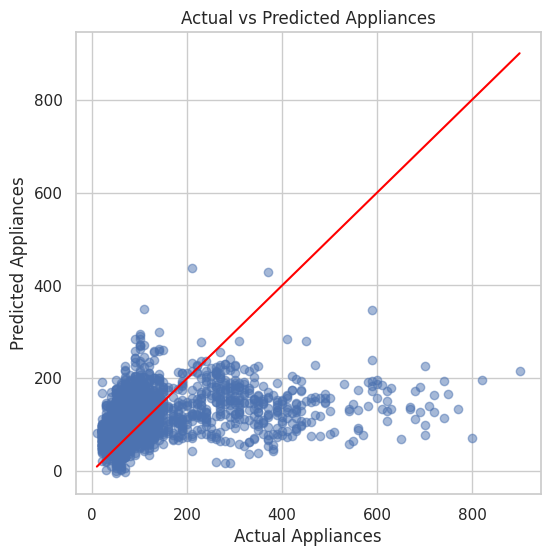

In [53]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.title("Actual vs Predicted Appliances")
plt.xlabel("Actual Appliances")
plt.ylabel("Predicted Appliances")
plt.show()

## 11 - Kesimpulan

Dataset Appliances Energy Prediction digunakan untuk memprediksi `Appliances` berdasarkan sensor suhu, kelembapan, cuaca, lights, dan fitur lingkungan. Dataset memiliki 19735 baris dan 29 kolom. Data tidak memiliki missing value dan memiliki 0 baris duplikat penuh.

EDA menunjukkan bahwa target `Appliances` cenderung miring ke kanan. Fitur dengan korelasi positif paling tinggi terhadap target adalah `lights`, sedangkan fitur dengan korelasi negatif paling kuat adalah `RH_out`. Kolom `date`, `rv1`, dan `rv2` dihapus sebelum modeling.

Data dibagi menjadi 80% data train dan 20% data test. Berdasarkan evaluasi, MAE test bernilai sekitar 52.544, RMSE test sekitar 91.171, dan R2 test sekitar 0.169.